<a href="https://colab.research.google.com/github/nguyenminhtien31251023643/NguyenMinhTien.31251023643/blob/main/NhanDangKhuonMat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/Ảnh Lớp IC"
img_width, img_height = 280, 280
batch_size = 34


train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')


In [8]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)


Found 1606 images belonging to 34 classes.


In [9]:

model = Sequential([
    Conv2D(32, (3, 3), activation="relu",padding= 'same' , input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(34, activation="softmax")
])


In [11]:

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])


model.summary()

epochs = 20
history = model.fit(train_generator, epochs=epochs)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 138, 138, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 67, 67, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    17,842,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,939,938 (68.44 MB)

 Trainable params: 17,939,938 (68.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 418s 9s/step - accuracy: 0.2702 - loss: 2.4562
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 401s 8s/step - accuracy: 0.3917 - loss: 2.0137
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 397s 8s/step - accuracy: 0.4707 - loss: 1.7438
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 451s 8s/step - accuracy: 0.5448 - loss: 1.4600
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 436s 8s/step - accuracy: 0.5934 - loss: 1.3072
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 397s 8s/step - accuracy: 0.6183 - loss: 1.2171
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 428s 9s/step - accuracy: 0.6476 - loss: 1.0953
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 423s 8s/step - accuracy: 0.7005 - loss: 0.9567
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 406s 8s/step - accuracy: 0.7042 - loss: 0.9443
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 403s 8s/step - accuracy: 0.7347 - loss: 0.8848
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 407s 8s/step - accuracy: 0.7653 - loss: 0.7314
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 394s 8s/step - accuracy:

In [12]:
model.save('ANHLOPICA.h5')

In [13]:
from keras.models import load_model
model5=load_model("ANHLOPICA.h5")

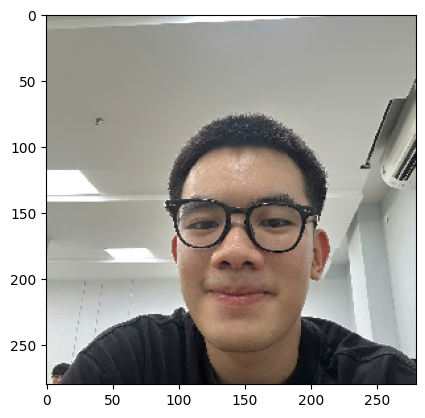

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Người tiên đoán: Mỹ Ngân


In [15]:

from keras.utils import load_img
import numpy as np

path = "/content/trongphuoc.jpg"

img = load_img(path, target_size=(280, 280))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 280, 280, 3)

prediction = np.argmax(model.predict(img))

class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")


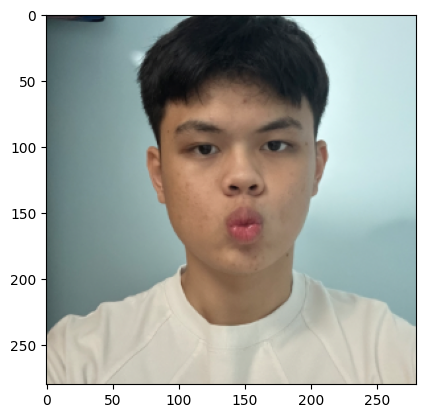

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Người tiên đoán: Trọng Duy


In [16]:

from keras.utils import load_img
import numpy as np

path = "/content/drive/MyDrive/Ảnh Lớp IC/Trọng Duy/10.png"

img = load_img(path, target_size=(280, 280))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 280, 280, 3)

prediction = np.argmax(model.predict(img))

class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")


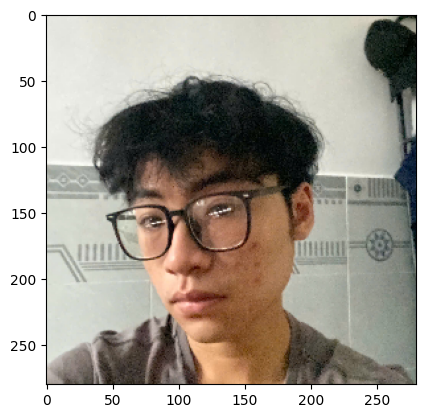

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Người tiên đoán: Hữu Tài


In [17]:

from keras.utils import load_img
import numpy as np

path = "/content/drive/MyDrive/Ảnh Lớp IC/Hữu Tài/z7869475650656_c77e90300714499b2ec8b017e6fd284f.jpg"

img = load_img(path, target_size=(280, 280))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 280, 280, 3)

prediction = np.argmax(model.predict(img))

class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")